# ANALISIS ESTADISTICO

El objetivo de esta sección es realizar un análisis más allá de los modelos descriptivos queremos saber cómo ocurren las cosas y qué relación guardan entre sí saber si existen correlaciones entre los datos lineales o no lineales y responder algunas preguntas básicas
- Pruebas de Hipótesis: Determinar si existe diferencia significativa en los datos (usando pruebas estadisticas).
- Análisis de Correlación No Lineal
- Respoder algunas pregunas 
    1. Que tipo de pago es mas comun 
    2. Hay relacion entre en tipo de pago y la review
    3. Gasto promedio por cliente y si hay alguna relacion estadistica con respecto al metodo de pago

In [26]:
import os, sys
sys.path.insert(0, r"d:\Supply Chain Resilience")
import matplotlib.pyplot as plt
import numpy as np
import duckdb 
import matplotlib
import pandas as pd
import matplotlib
from src.data_save import DataSave
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

In [27]:
ruta_datos_oro = DataSave(ruta=r"D:\Supply Chain Resilience\Dataset\03 Olist Gold")
tablas = ruta_datos_oro.cargar_todo()

📂 dim_customers.parquet cargado | Filas: 99,441
📂 dim_geolocation.parquet cargado | Filas: 1,000,163
📂 dim_orders.parquet cargado | Filas: 99,441
📂 dim_orders_reviews.parquet cargado | Filas: 99,224
📂 dim_order_items.parquet cargado | Filas: 112,650
📂 dim_order_payments.parquet cargado | Filas: 103,886
📂 dim_products.parquet cargado | Filas: 32,951
📂 dim_sellers.parquet cargado | Filas: 3,095
📂 dim_time.parquet cargado | Filas: 98,875
📂 fact_sales.parquet cargado | Filas: 117,604


In [28]:
def resumen_tabla(dataframes: dict) -> pd.DataFrame:
  filas = []
  for name, df in dataframes.items():
    null_cols = df.columns[df.isnull().any()].tolist()
    filas.append({
        "dataset":         name,
        "n_filas":         df.shape[0],
        "n_columnas":      df.shape[1],
        "val_nulos":     df.isnull().sum().sum(),
        "qty_null_columns": len(null_cols),
        "null_columns":    ", ".join(null_cols) if null_cols else ""
    })
  return pd.DataFrame(filas)

def styling_pandas(df: dict) -> pd.DataFrame:
  # Get the names of the numeric columns
  num_cols_names = df.select_dtypes(include='number').columns.tolist()
  styled = (
      df.style
      .background_gradient(
          cmap="Blues",
          subset=num_cols_names # Pass the list of column names here
      )
      .set_properties(**{
          "font-size": "12px",
          "border": "1px solid #ddd",
          "text-align": "center"
      })
      .set_table_styles([{
          "selector": "th",
          "props": [
              ("background-color", "#2c3e50"),
              ("color", "white"),
              ("font-size", "13px"),
              ("text-align", "center"),
              ("padding", "8px")
          ]
      }])
      .format({
          "n_filas":          "{:,}", # Corrected column name
          "val_nulos":     "{:,}", # Corrected column name
          "qty_null_columns": "{:,}"
      })
  )
  return styled

In [29]:
def resumen_columnas(tabla: dict) -> pd.DataFrame:
    filas = []
    for name, df in tablas.items():
      for col in df.columns:
          val_null = df[col].isnull().sum()
          dtype = str(df[col].dtype)

          filas.append({
              "nombre_df":  name,
              "nombre_col":  col,
              "val_null":  val_null,
              "tipo":  dtype,
          })

    return pd.DataFrame(filas)


In [30]:
# hacemos la conexion con db guardo en con
con = duckdb.connect()
# registramos cada tabla
for nombre, df in tablas.items():
    con.register(nombre, df)
# usamos la conexion especifica y no la global duckdb
def query(sql: str, conexion=con) -> pd.DataFrame:
    try:
        resultado = conexion.query(sql).df()
        return resultado
    except Exception as e:
        print(f"Error en la query: {e}")
        return pd.DataFrame()

In [31]:
# hacemos la conexion con db guardo en con
con = duckdb.connect()
# registramos cada tabla
for nombre, df in tablas.items():
    con.register(nombre, df)
# usamos la conexion especifica y no la global duckdb
def query(sql: str, conexion=con) -> pd.DataFrame:
    try:
        resultado = conexion.query(sql).df()
        return resultado
    except Exception as e:
        print(f"Error en la query: {e}")
        return pd.DataFrame()

Intentamos responder nuestra pregunta número uno ¿qué tipo de pago es más común y analizaremos después si hay alguna relación entre el tipo de pago y la review?

In [32]:
query_2 = """
WITH conteo_frecuencias AS (
    SELECT 
        f.customer_id,
        op.payment_type,
        sum(f.price) AS total,
        COUNT(*) AS total_usos,
        MIN(f.order_purchase_timestamp) AS primera,
        MAX(f.order_purchase_timestamp) AS ultima
    FROM fact_sales f
    JOIN dim_order_payments op ON f.order_id = op.order_id
    GROUP BY f.customer_id, op.payment_type
),
ranking_pagos AS (
    SELECT 
        customer_id,
        payment_type,
        total,
        primera,
        ultima,
        ROW_NUMBER() OVER(
            PARTITION BY customer_id 
            ORDER BY total_usos DESC, ultima DESC -- En caso de empate, el pago más reciente gana
        ) AS rnk
    FROM conteo_frecuencias
)

SELECT 
    customer_id,
    primera AS primera_compra,
    total,
    ultima AS ultima_compra,
    payment_type AS mas_comun
FROM ranking_pagos
WHERE rnk = 1;
"""
resp_2 = query(query_2)
resp_2 

,customer_id,primera_compra,total,ultima_compra,mas_comun
0,fd58e83220f721f32907fe4d3ff345d3,2018-03-01 14:27:17,72.99,2018-03-01 14:27:17,credit_card
1,fd5c9b3e358a87a8fb22ea9a996949f4,2017-12-02 12:37:39,120.90,2017-12-02 12:37:39,credit_card
2,fd6d24826df20a47edc27155e5c613ae,2017-11-09 19:16:07,139.90,2017-11-09 19:16:07,credit_card
3,fd6eb9abeb780067580abc6384a9ef39,2018-06-20 13:09:20,228.00,2018-06-20 13:09:20,credit_card
4,fd6f61091eaa73b3f00aadc3e396c306,2017-11-25 13:55:57,120.00,2017-11-25 13:55:57,credit_card
...,...,...,...,...,...
98660,ffbf82fe167e7156e06fc1778d6b1cea,2017-08-05 09:08:55,891.00,2017-08-05 09:08:55,voucher
98661,ffc18c67e76fe18432856ef05b0b5edd,2017-08-12 16:25:03,117.79,2017-08-12 16:25:03,boleto
98662,ffd14a431366fce43a5e77826b9f2ffa,2017-11-25 18:11:13,64.90,2017-11-25 18:11:13,boleto
98663,ffe642291d0c94528389d64c07ec8341,2017-07-02 11:53:10,16.99,2017-07-02 11:53:10,credit_card


In [33]:
df_agrupado = (
    resp_2.groupby('customer_id')
    .agg(
        gasto_total    = ('total', 'sum'),
        primera_compra = ('primera_compra', 'min'),
        ultima_compra  = ('ultima_compra', 'max')
    )
    .reset_index()
    .sort_values('gasto_total', ascending=False)
)
df_agrupado

,customer_id,gasto_total,primera_compra,ultima_compra
59739,9af2372a1e49340278e7c1ef8d749f34,330134.55,2017-04-20 12:45:34,2017-04-20 12:45:34
85945,de832e8dbb1f588a47013e53feaa67cc,151985.40,2017-05-29 14:06:33,2017-05-29 14:06:33
38322,63b964e79dee32a3587651701a2b8dbf,108768.00,2018-02-14 16:34:27,2018-02-14 16:34:27
81180,d1ea705f2fdd8f98eff86c2691652e60,78258.18,2018-06-26 22:43:32,2018-06-26 22:43:32
42704,6f241d5bbb142b6f764387c8c270645a,57120.84,2018-05-10 18:46:19,2018-05-10 18:46:19
...,...,...,...,...
34889,5ac9fcc9259df95cf14d27238b112148,2.99,2018-02-02 00:01:31,2018-02-02 00:01:31
81495,d2c63ad286e3ca9dd69218008d61ff81,2.90,2017-01-05 12:06:36,2017-01-05 12:06:36
9383,184e8e8e48937145eb96c721ef1f0747,2.29,2017-09-13 19:13:20,2017-09-13 19:13:20
61571,9f9d249355f63c5c1216a82b802452c1,0.85,2018-04-24 20:15:21,2018-04-24 20:15:21


In [34]:
import datetime as dt

df_agrupado['ultima_compra'] = pd.to_datetime(df_agrupado['ultima_compra'])
df_agrupado['primera_compra'] = pd.to_datetime(df_agrupado['primera_compra'])
df_agrupado['dias_como_cliente'] = (df_agrupado['ultima_compra']- df_agrupado['primera_compra']).dt.days
df_agrupado['Gasto_promedio_por_mes'] = (df_agrupado['gasto_total'] / df_agrupado['dias_como_cliente'].replace(0, 1)).round(2)

print(f"Gasto promedio al dia por cliente: ${df_agrupado['gasto_total'].mean():,.2f}")
print(f"Días promedio como cliente: {df_agrupado['dias_como_cliente'].mean():.0f} días")
print(f"Tipo de combra mas comun : \n{resp_2.groupby('mas_comun').agg(tipo_pago = ('mas_comun', 'count'))}")

Gasto promedio al dia por cliente: $165.88
Días promedio como cliente: 0 días
Tipo de combra mas comun : 
             tipo_pago
mas_comun             
boleto           19614
credit_card      74686
debit_card        1521
voucher           2844


De esta información podemos concluir que el método de pago más común

1. es el de boleto la mayor cantidad de nuestros datos se basan en estos.

2. el método de tarjeta de crédito es el segundo más usado.

3. seguidamente de la tarjeta de débito.

4.  finalmente el método de voucher

También obtenemos que el gasto promedio por cliente al día es de 165.88 y que la mayoría de nuestros clientes hace solo una compra a la vez

## ANALISIS DE VARIANZAS

Ahora vamos a determinar si existe diferencia significativa en las reseñas de los clientes según el método de pago.

El objetivo de un análisis de varianza anova es comparar las medias de varios grupos para determinar si existen diferencias observadas significativas, es decir, si se deben al azar o reflejan situaciones reales, para este analisis se deben cumplir 3 supuestos:

1. Los datos han de ser independientes en este caso se asume por la naturaleza del proyecto.
2. Los residuos deben seguir una distribución normal
3. La varianza de los datos deben tener una distribución similar

In [35]:
query_1 ="""
WITH datos AS (
  SELECT 
    op.payment_type AS tipo_pago,
    f.order_id      AS ordenes,
    r.review_score  AS calificacion_promedio,
    ROW_NUMBER() OVER (PARTITION BY f.order_id ORDER BY f.order_id ) AS rn
  FROM fact_sales f
  JOIN dim_order_payments op
    ON f.order_id = op.order_id
  LEFT JOIN dim_orders_reviews r
    ON f.order_id = r.order_id
  WHERE r.review_score IS NOT NULL) 
SELECT 
  tipo_pago,
  ordenes,
  calificacion_promedio
FROM datos
WHERE rn = 1;
"""

In [36]:
review_tipo_pago= query(query_1)
review_tipo_pago

,tipo_pago,ordenes,calificacion_promedio
0,credit_card,e49e382e440b76f65be6ce311948835c,1
1,credit_card,4d177a59bedcc26843b61e6b4078e4fc,5
2,boleto,4696eb8d8514a43861661047a268e6aa,1
3,credit_card,8780697430377d453d0cf3f29848a515,5
4,credit_card,137f57a202d83cd03668234859e1b2a9,4
...,...,...,...
97911,credit_card,453887e7d1a2fbd4beda6f9dbeaf1b4d,4
97912,credit_card,8690e66d045afe5a5bd8b559cacd335a,1
97913,credit_card,3b253446924d20b4bb7220dfa7c68149,5
97914,credit_card,08eb6a0ddc93b1cf16dd629389dc691b,5


Para que los datos sean estadísticamente significativos cada clase debe tener al menos 30 valores esto debido al **teorema de límite central** que establece que los datos se distribuyen de manera normal a medida que aumenta la muestra.
De esta forma los test paramétricos como ANOVA tienen la suficiente significancia estadística para dar conclusiones correctas

Y en efecto notemos que la cantidad de muestras por cada tipo de pago supera las 30 muestras por lo tanto el análisis que realizaremos es estadísticamente significativo

In [37]:
print(review_tipo_pago.groupby('tipo_pago')['calificacion_promedio'].count())
print(review_tipo_pago.groupby('tipo_pago')['calificacion_promedio'].mean())


tipo_pago
boleto         19471
credit_card    74156
debit_card      1514
voucher         2775
Name: calificacion_promedio, dtype: int64
tipo_pago
boleto         4.106928
credit_card    4.104604
debit_card     4.179657
voucher        4.067027
Name: calificacion_promedio, dtype: float64


### Supuestos de normalidad

In [38]:

grupos = [
    review_tipo_pago[review_tipo_pago['tipo_pago'] == 'credit_card']['calificacion_promedio'],
    review_tipo_pago[review_tipo_pago['tipo_pago'] == 'boleto']['calificacion_promedio'],
    review_tipo_pago[review_tipo_pago['tipo_pago'] == 'voucher']['calificacion_promedio'],
    review_tipo_pago[review_tipo_pago['tipo_pago'] == 'debit_card']['calificacion_promedio']
]


modelo = ols('calificacion_promedio ~ tipo_pago', data=review_tipo_pago).fit()

residuos = modelo.resid

Ahora con los residuos obtenidos anteriormente aplicamos un test de shapiro wilk

Recordemos que si mis residuos no son normales entonces mi análisis estadístico ANOVA podría dar conclusiones incorrectas

c:\Users\Axel MG\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 97916.
  res = hypotest_fun_out(*samples, **kwds)


Estadístico de Shapiro-Wilk: 0.6893
P-valor: 4.8455e-145
>>> Los residuos NO siguen una distribución normal (Rechazamos H0).


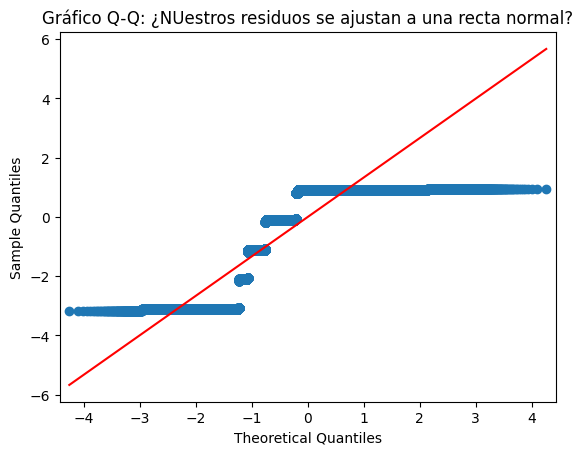

In [45]:
stat, p_valor = stats.shapiro(residuos)
print(f"Estadístico de Shapiro-Wilk: {stat:.4f}")
print(f"P-valor: {p_valor:.4e}")
alpha = 0.05
if p_valor > alpha:
    print(">>> Los residuos siguen una distribución normal (Aceptamos H0).")
else:
    print(">>> Los residuos NO siguen una distribución normal (Rechazamos H0).")
sm.qqplot(residuos, line='s')
plt.title("Gráfico Q-Q: ¿NUestros residuos se ajustan a una recta normal?")
plt.show()

Tras aplicar el análisis estadístico obtuvimos un p-valor menor que el nivel de significancia por lo tanto concluimos que los residuos no tienen la distribución normal y rechazamos la hipótesis nula aceptando la hipótesis alternativa es decir nuestros residuos no siguen una distribución normal por lo tanto no podemos obtener conclusiones significativas con nuestro modelo anova sin embargo para concluir ese análisis realizaremos la prueba de levine para analizar la homosedasticidad

In [40]:
stat, p_levene = stats.levene(*grupos)
print("Resultados de la Prueba de Levene ")
print(f"Estadístico W: {stat:.4f}")
print(f"P-valor: {p_levene:.4f}")

alpha = 0.05
if p_levene > alpha:
    print("Conclusión: Las varianzas son iguales (Homocedasticidad cumplida).")
else:
    print("Conclusión: Las varianzas son significativamente distintas (Heterocedasticidad).")

Resultados de la Prueba de Levene 
Estadístico W: 2.3551
P-valor: 0.0699
Conclusión: Las varianzas son iguales (Homocedasticidad cumplida).


De la misma forma al analizar la heterocedasticidad mediante la prueba de levene obtuvimos un prevalor menor a nivel de significancia esto nos indica que las varianzas entre los diferentes grupos son significativamente distintas es decir no podemos comparar los grupos entre sí debido a que la comparación no es justa

### 2. prueba de Kruskal-Wallis
Debido a que no podemos realizar un análisis anova procederemos con un modelo no paramétrico llamado Kruskal-Wallis.

In [41]:
# 
stat_kw, p_kw = stats.kruskal(*grupos)

print(f"P-valor Kruskal-Wallis: {p_kw:.4e}")

if p_kw < 0.05:
    print("¡EXISTE una diferencia significativa!")
    print("El método de pago SÍ influye en cómo califican los clientes.")
else:
    print("NO existe diferencia significativa.")
    print("El método de pago es indiferente para la satisfacción del cliente.")

P-valor Kruskal-Wallis: 4.7375e-02
¡EXISTE una diferencia significativa!
El método de pago SÍ influye en cómo califican los clientes.


Tras realizar esta prueba estadística obtenemos un p valor menor al nivel de significancia es decir sí existe una diferencia significativa entre la calificación entre los diferentes métodos de pago

Sin embargo algo importante que hay que destacar es que este Test nos dice que hay una diferencia, pero no nos dice entre qué clases por lo que tenemos que aplicar una prueba de dunn para saber exactamente qué clases son las que difieren estadísticamente

In [42]:
import scikit_posthocs as sp

dunn_df = sp.posthoc_dunn(review_tipo_pago, val_col='calificacion_promedio', group_col='tipo_pago', p_adjust='holm')
print(dunn_df)

               boleto  credit_card  debit_card   voucher
boleto       1.000000     0.519482    0.099577  0.418989
credit_card  0.519482     1.000000    0.113329  0.338721
debit_card   0.099577     0.113329    1.000000  0.036760
voucher      0.418989     0.338721    0.036760  1.000000


Después de aplicar el test notemos que el único p valor menor al 0.05 fue el de debit_card vs voucher.
Como conclusión la calificación del cliente no depende del método de pago que hagan ya que no son significativamente distintos excepto en la relación entre el pago con tarjeta de débito y voucher.

Dejamos algunas preguntas pendientes debido a que el método de resolución de esto sería similar a la forma en la cual tratamos los problemas anteriores y buscamos alternativas más robustas para poder hacer clasificaciones, preducciones y agrupamientos de clientes.

En la siguiente sección de este notebook nos enfrentaremos a problemas usando modelos de Machine learning.
Para finalmente a entrar a modelos deep learning.
